# Telco Customer Churn —  Regression Analysis

### Simple Linear Regression & Multiple Linear Regression

**Objective:** Use `TotalCharges` as a numeric target and understand how customer tenure and other numeric variables relate to total charges.

> **Important:** `Churn` is a Yes/No classification target, so it is not used as the target for linear regression in this notebook.


## 1. Import Libraries

In [37]:
import warnings
warnings.filterwarnings('ignore')

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [39]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [42]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# **Simple Linear Regression**

We use one independent variable:

**Tenure → TotalCharges**

The idea is to check whether customer tenure can help predict total charges.


In [43]:
X = df[['tenure']]
Y = df[['TotalCharges']]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y
)

In [45]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()


In [46]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
Predicted_values = model.predict(X_test)

print("First 10 predicted values:")
print(Predicted_values)


First 10 predicted values:
[[-101.22340001]
 [3981.71339845]
 [1789.0251178 ]
 ...
 [2923.17422848]
 [ 352.43624426]
 [3225.61399133]]


## Simple Linear Regression Equation

In [48]:
print("Intercept:", round(float(model.intercept_[0]), 2))
print("Coefficient:", round(float(model.coef_[0][0]), 2))

print("\nModel:")
print(
    "TotalCharges =",
    round(float(model.intercept_[0]), 2),
    "+",
    round(float(model.coef_[0][0]), 2),
    "* tenure"
)


Intercept: -176.83
Coefficient: 75.61

Model:
TotalCharges = -176.83 + 75.61 * tenure


In [49]:
model.score(X_train,Y_train)  # Training Accuracy

0.676668724330455

In [50]:
model.score(X_test,Y_test) # Model Efficency

0.6972431079232427

In [51]:
model.intercept_  # Intercept(c)

array([-176.83334072])

In [52]:
error = Y_test - Predicted_values
error

,TotalCharges
3725,172.023400
3711,282.536602
6285,-426.175118
5416,1402.866720
1793,-3497.482391
...,...
2469,-1416.554940
3158,-305.795592
1515,-46.124228
4018,124.613756


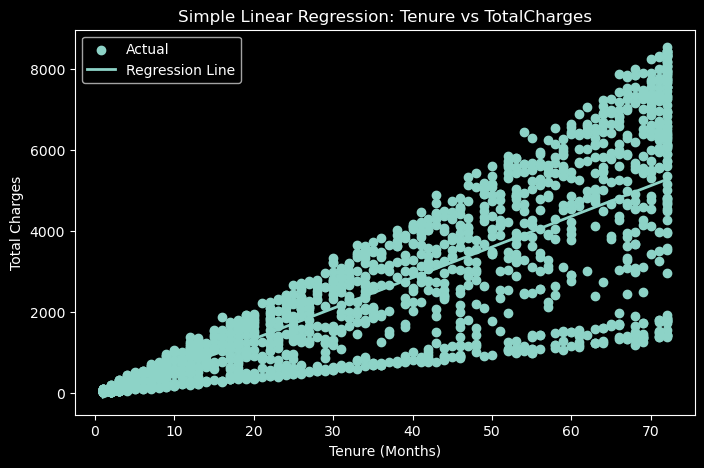

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test,
    Y_test,
    marker="o",
    label="Actual"
)

sorted_indices = X_test["tenure"].argsort()

plt.plot(
    X_test.iloc[sorted_indices],
    Predicted_values[sorted_indices],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")
plt.title("Simple Linear Regression: Tenure vs TotalCharges")
plt.legend()
plt.show()


##  Simple Regression Evaluation

In [54]:
from sklearn.metrics import * 
MSE = mean_squared_error(Y_test, Predicted_values)
MAE = mean_absolute_error(Y_test, Predicted_values)
RMSE = np.sqrt(MSE)
R_square = r2_score(Y_test, Predicted_values)

print("MSE :", round(MSE, 2))
print("MAE :", round(MAE, 2))
print("RMSE:", round(RMSE, 2))
print("R²  :", round(R_square, 4))


MSE : 1615418.64
MAE : 874.49
RMSE: 1270.99
R²  : 0.6972


### Simple Regression Insight

- The coefficient tells us how `TotalCharges` changes with one additional month of tenure.
- A positive coefficient means total charges generally increase as tenure increases.
- `R²` tells us how much variation in `TotalCharges` is explained by tenure alone.
- `MAE` and `RMSE` show the prediction error.


# **Multiple Linear Regression**

Now we use three independent variables:

- `tenure`
- `MonthlyCharges`
- `SeniorCitizen`

Target:

- `TotalCharges`

So the model becomes:

**tenure + MonthlyCharges + SeniorCitizen → TotalCharges**


In [55]:
X = df[
    [
        "tenure",
        "MonthlyCharges",
        "SeniorCitizen"
    ]
]

Y = df[["TotalCharges"]]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y
)


In [56]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
Predicted_values_multiple = multiple_model.predict(X_test)

print("First 10 predicted values:")
print(Predicted_values_multiple[:10])


First 10 predicted values:
[[ 5293.01503413]
 [ 4728.15388865]
 [ 2978.34409575]
 [ 1918.87425936]
 [ 2504.42443423]
 [ 1916.36344636]
 [-1028.8780357 ]
 [ -452.40539317]
 [  475.61058238]
 [-1208.24980747]]


##  Multiple Regression Coefficients

In [58]:
multiple_model.coef_    # Slope(m)

array([[ 65.79076602,  36.00105259, -84.6297239 ]])

In [59]:
multiple_model.intercept_     # c

array([-2168.84442045])

In [60]:
multiple_model.score(X_train,Y_train)

0.8958358326023895

In [61]:
multiple_model.score(X_test,Y_test)

0.8930736528203993

In [62]:
from sklearn.metrics import * 

r_square = r2_score(Y_test, Predicted_values_multiple)

print(r_square)

0.8930736528203993


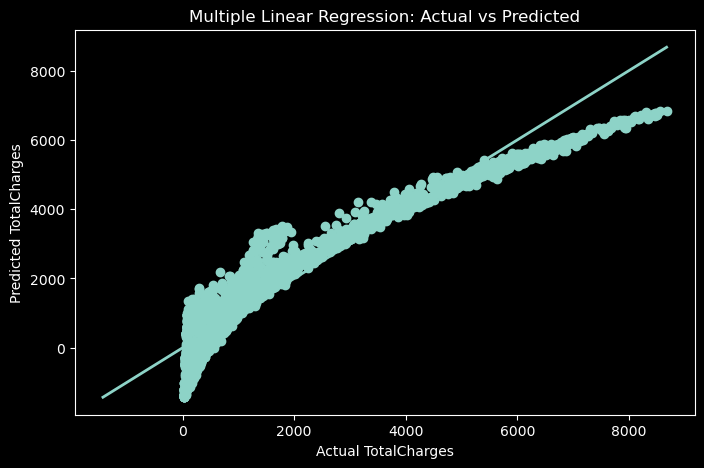

In [63]:
plt.style.use("dark_background")
plt.figure(figsize=(8, 5))

plt.scatter(
    Y_test,
    Predicted_values_multiple,
    marker="o"
)

minimum = min(
    float(Y_test["TotalCharges"].min()),
    float(Predicted_values_multiple.min())
)

maximum = max(
    float(Y_test["TotalCharges"].max()),
    float(Predicted_values_multiple.max())
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)

plt.xlabel("Actual TotalCharges")
plt.ylabel("Predicted TotalCharges")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()


##  Multiple Regression Evaluation

In [64]:
MSE_multiple = mean_squared_error(
    Y_test,
    Predicted_values_multiple
)

MAE_multiple = mean_absolute_error(
    Y_test,
    Predicted_values_multiple
)

RMSE_multiple = np.sqrt(MSE_multiple)

R_square_multiple = r2_score(
    Y_test,
    Predicted_values_multiple
)

print("MSE :", round(MSE_multiple, 2))
print("MAE :", round(MAE_multiple, 2))
print("RMSE:", round(RMSE_multiple, 2))
print("R²  :", round(R_square_multiple, 4))


MSE : 534595.78
MAE : 582.61
RMSE: 731.16
R²  : 0.8931


### Multiple Regression Insight

- Multiple regression uses more than one input variable.
- `tenure` represents how long the customer has stayed.
- `MonthlyCharges` represents the customer's monthly billing amount.
- `SeniorCitizen` is a binary numeric variable: 0 or 1.
- We compare `R²`, `MAE`, and `RMSE` with the simple model to see whether the additional variables improve prediction.


##  ***Compare Both Models***

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        MAE,
        MAE_multiple
    ],
    "RMSE": [
        RMSE,
        RMSE_multiple
    ],
    "R2": [
        R_square,
        R_square_multiple
    ]
})

comparison.round(2)


,Model,MAE,RMSE,R2
0,Simple Linear Regression,874.49,1270.99,0.70
1,Multiple Linear Regression,582.61,731.16,0.89


In [66]:
if R_square_multiple > R_square:
    print("Multiple Linear Regression has a higher R².")
else:
    print("Simple Linear Regression has a higher R².")

if RMSE_multiple < RMSE:
    print("Multiple Linear Regression has a lower RMSE.")
else:
    print("Simple Linear Regression has a lower RMSE.")


Multiple Linear Regression has a higher R².
Multiple Linear Regression has a lower RMSE.


#  ***Final Conclusion***

### What we learned

1. **Simple Linear Regression** used `tenure` to predict `TotalCharges`.
2. **Multiple Linear Regression** used `tenure`, `MonthlyCharges`, and `SeniorCitizen`.
3. We evaluated both models using **MSE, MAE, RMSE, and R²**.
4. We compared the models to understand whether additional variables improved prediction.

### Important business point

The actual Telco business problem is usually to predict **customer churn**. Since `Churn` contains `Yes/No`, that is a **classification problem**, not a regression problem.

For actual churn prediction, the next step should be **Logistic Regression / Decision Tree / Random Forest**, rather than Linear Regression.
